# Inteligência Artificial Aplicada - 2026/1
# Trabalho 5 - Redes Convolutivas

### Por: Maria Giovanna Gonçalves Sales


Este notebook resolve o problema de reconhecimento facial dos 40 indivíduos da base ORL utilizando duas arquiteturas de redes convolutivas:

- **Rede 1:** CONV - BATCH - RELU - POOLING - FULLCONNECT - SOFTMAX
- **Rede 2:** CONV - BATCH - RELU - POOLING - CONV - BATCH - RELU - POOLING - CONV - BATCH - RELU - POOLING - FULLCONNECT - SOFTMAX

## 1. Importação das bibliotecas

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (InputLayer, Conv2D, BatchNormalization,
                                      MaxPooling2D, Flatten, Dense, Dropout)
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
import zipfile

DATASET_ZIP = "ORL_dataset.zip"
DATASET_DIR = "base_de_dados_ORL"

if not os.path.isdir(DATASET_DIR) and os.path.exists(DATASET_ZIP):
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
        zip_ref.extractall(".")

print("Pastas encontradas:", sorted(os.listdir(DATASET_DIR), key=lambda x: int(x)))


Pastas encontradas: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40']


In [ ]:
IMG_HEIGHT = 92
IMG_WIDTH = 112
NUM_CLASSES = 40

X = []
y = []

for person_id in range(1, NUM_CLASSES + 1):
    person_folder = os.path.join(DATASET_DIR, str(person_id))
    for img_id in range(1, 11):
        img_path = os.path.join(person_folder, f"{img_id}.png")
        img = Image.open(img_path).convert('L')  # garante escala de cinza
        img_array = np.array(img, dtype=np.float32)
        X.append(img_array)
        y.append(person_id - 1)  # labels de 0 a 39

X = np.array(X)
y = np.array(y)

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Número de classes:", len(np.unique(y)))


Shape de X: (400, 112, 92)
Shape de y: (400,)
Número de classes: 40


### 2.1 Visualização de algumas amostras

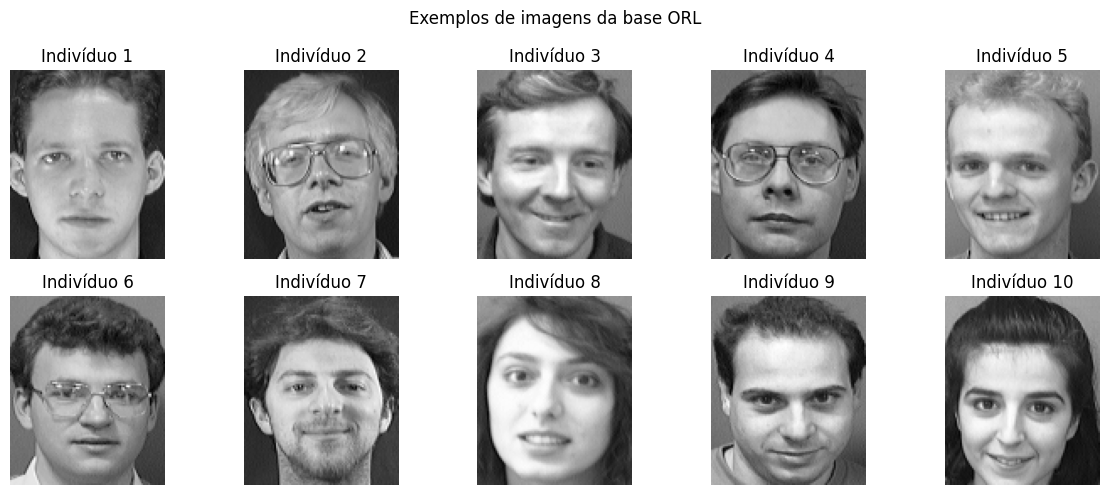

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = i * 10  # uma imagem de cada uma das primeiras 10 pessoas
    ax.imshow(X[idx], cmap='gray')
    ax.set_title(f"Indivíduo {y[idx] + 1}")
    ax.axis('off')
plt.suptitle("Exemplos de imagens da base ORL")
plt.tight_layout()
plt.show()


## 3. Pré-processamento

- Normalização dos valores de pixel para o intervalo [0, 1]
- Inclusão da dimensão de canal (imagens em escala de cinza -> 1 canal)
- Divisão em treino (70%) e teste (30%), de forma estratificada por indivíduo
- Conversão dos rótulos para one-hot encoding (necessário para a saída softmax)

In [ ]:
# Normalização
X = X / 255.0

# Adiciona dimensão de canal -> (N, altura, largura, 1)
X = X[..., np.newaxis]

# Divisão estratificada 70% treino / 30% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste :", X_test.shape, y_test.shape)

# One-hot encoding dos rótulos
y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_test_oh = to_categorical(y_test, NUM_CLASSES)


Treino: (280, 112, 92, 1) (280,)
Teste : (120, 112, 92, 1) (120,)


## 4. Arquitetura 1

`CONV - BATCH - RELU - POOLING - FULLCONNECT - SOFTMAX-CLASSIFIER`

In [ ]:
reg = 1e-4

model1 = Sequential([
    InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    Conv2D(16, kernel_size=(3, 3), strides=(2, 2), padding='same',
           kernel_regularizer=tf.keras.regularizers.l2(reg)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D(pool_size=(4, 4)),

    Flatten(),
    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(reg)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 46, 56, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 46, 56, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 46, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 11, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2464)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       157,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,584 (627.28 KB)

 Trainable params: 160,552 (627.16 KB)

 Non-trainable params: 32 (128.00 B)

In [ ]:
EPOCHS = 60
BATCH_SIZE = 16

history1 = model1.fit(
    X_train, y_train_oh,
    validation_data=(X_test, y_test_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)


Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.0607 - loss: 4.0391 - val_accuracy: 0.0250 - val_loss: 3.6971
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.0429 - loss: 3.5859 - val_accuracy: 0.0417 - val_loss: 3.6905
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.0571 - loss: 3.4932 - val_accuracy: 0.0167 - val_loss: 3.6931
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.0750 - loss: 3.3552 - val_accuracy: 0.0250 - val_loss: 3.6934
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1107 - loss: 3.2441 - val_accuracy: 0.0250 - val_loss: 3.6851
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1107 - loss: 3.0663 - val_accuracy: 0.0500 - val_loss: 3.6634
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1536 - loss: 3.0783 - val_accuracy: 0.0750 - val_loss: 3.6337
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1464 - loss: 2.9648 - val_accuracy: 0.1083 - v

### 4.1 Gráfico de acurácia - Arquitetura 1

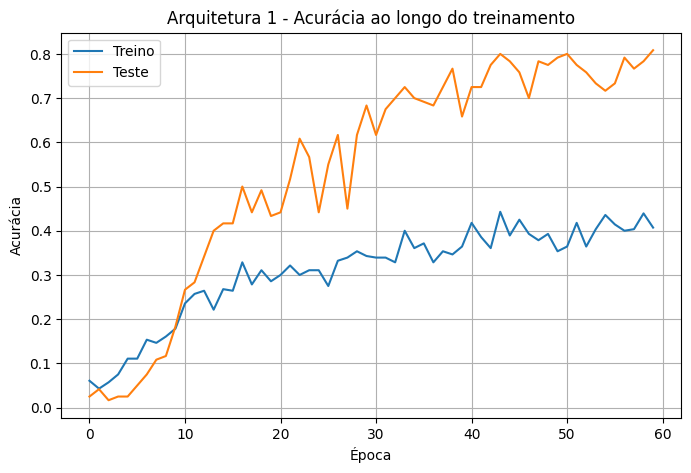

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history1.history['accuracy'], label='Treino')
plt.plot(history1.history['val_accuracy'], label='Teste')
plt.title('Arquitetura 1 - Acurácia ao longo do treinamento')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()


### 4.2 Avaliação - Arquitetura 1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Acurácia (Arquitetura 1) no conjunto de teste: 80.83%


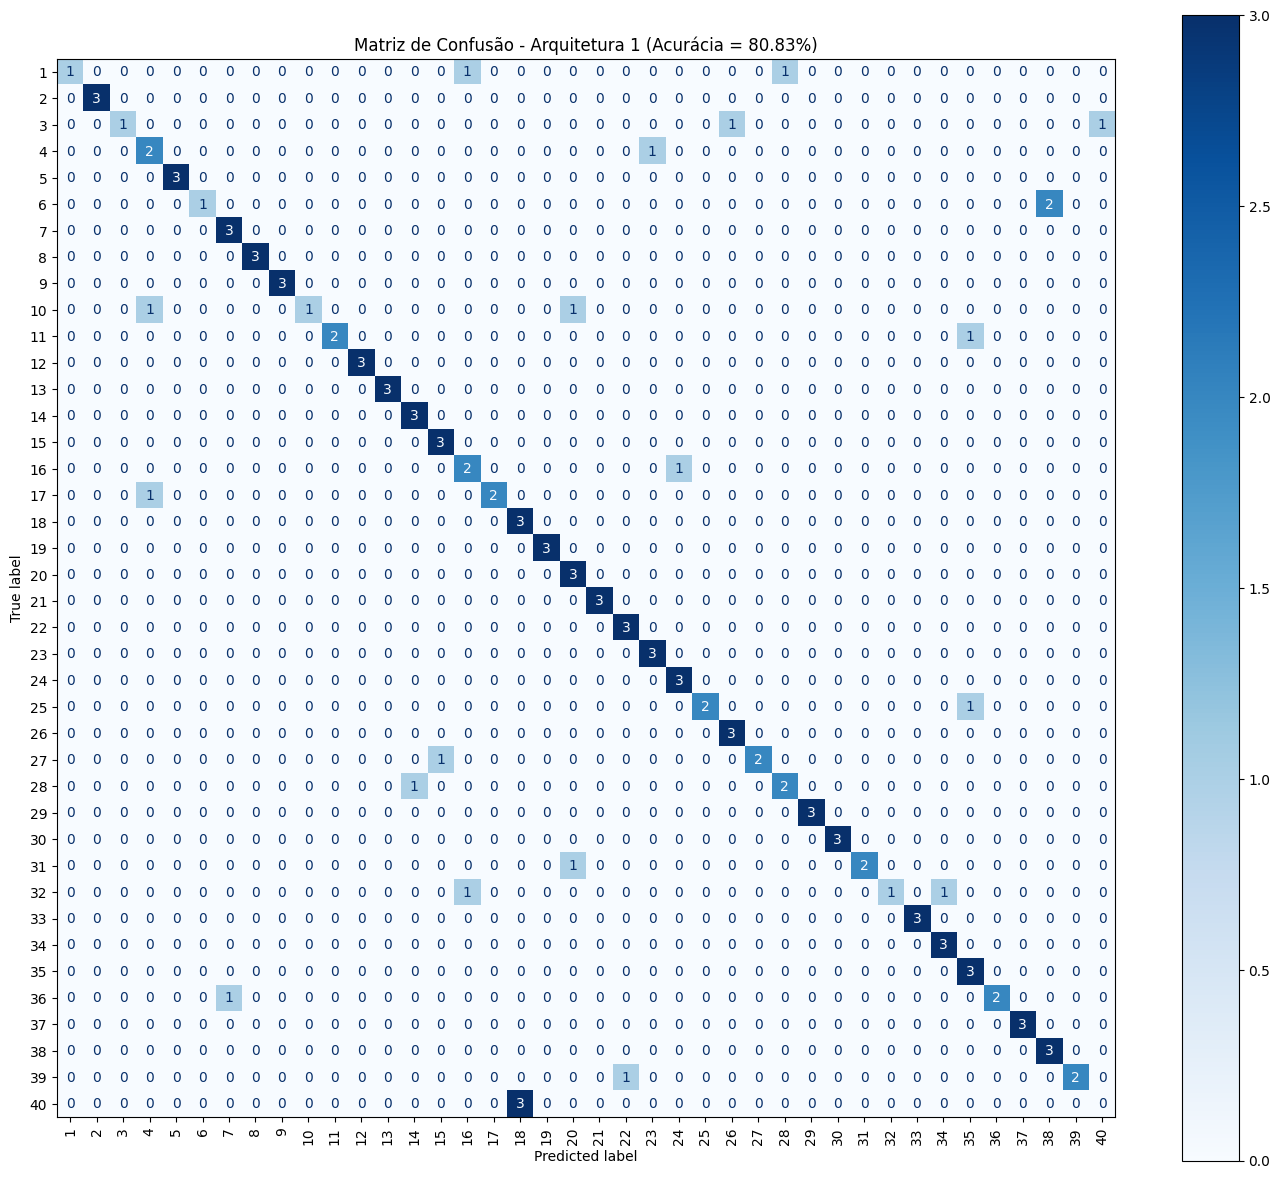

In [ ]:
y_pred1 = np.argmax(model1.predict(X_test), axis=1)
y_true = y_test

acc1 = accuracy_score(y_true, y_pred1)
print(f"Acurácia (Arquitetura 1) no conjunto de teste: {acc1*100:.2f}%")

cm1 = confusion_matrix(y_true, y_pred1, labels=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(14, 12))
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1,
                                display_labels=[str(i+1) for i in range(NUM_CLASSES)])
disp1.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title(f'Matriz de Confusão - Arquitetura 1 (Acurácia = {acc1*100:.2f}%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 5. Arquitetura 2

`CONV - BATCH - RELU - POOLING - CONV - BATCH - RELU - POOLING - CONV - BATCH - RELU - POOLING - FULLCONNECT - SOFTMAX-CLASSIFIER`

Três blocos convolutivos (cada um com convolução, normalização em lote, ReLU e
pooling), seguidos de camada totalmente conectada e classificador softmax.

In [ ]:
reg2 = 1e-4

model2 = Sequential([
    InputLayer(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    # Bloco 1
    Conv2D(32, kernel_size=(3, 3), strides=(2, 2), padding='same',
           kernel_regularizer=tf.keras.regularizers.l2(reg2)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Bloco 2
    Conv2D(64, kernel_size=(3, 3),  strides=(2, 2), padding='same',
           kernel_regularizer=tf.keras.regularizers.l2(reg2)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Bloco 3
    Conv2D(128, kernel_size=(3, 3), strides=(2, 2), padding='same',
           kernel_regularizer=tf.keras.regularizers.l2(reg2)),
    BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(reg2)),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 46, 56, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 46, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 46, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 23, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 12, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 3, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 3, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 3, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 1, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,640 (662.66 KB)

 Trainable params: 169,192 (660.91 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
EPOCHS2 = 60
BATCH_SIZE2 = 16

history2 = model2.fit(
    X_train, y_train_oh,
    validation_data=(X_test, y_test_oh),
    epochs=EPOCHS2,
    batch_size=BATCH_SIZE2,
    verbose=1
)


Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.0500 - loss: 3.9894 - val_accuracy: 0.0250 - val_loss: 3.7208
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.2536 - loss: 2.9001 - val_accuracy: 0.0250 - val_loss: 3.7153
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.4929 - loss: 1.9823 - val_accuracy: 0.0500 - val_loss: 3.7298
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.6464 - loss: 1.4629 - val_accuracy: 0.0250 - val_loss: 3.7523
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8500 - loss: 0.9165 - val_accuracy: 0.0250 - val_loss: 3.7969
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8964 - loss: 0.6259 - val_accuracy: 0.0250 - val_loss: 3.8652
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9571 - loss: 0.3480 - val_accuracy: 0.0250 - val_loss: 3.9339
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9500 - loss: 0.3116 - val_accuracy: 0.0250 - v

### 5.1 Gráfico de acurácia - Arquitetura 2

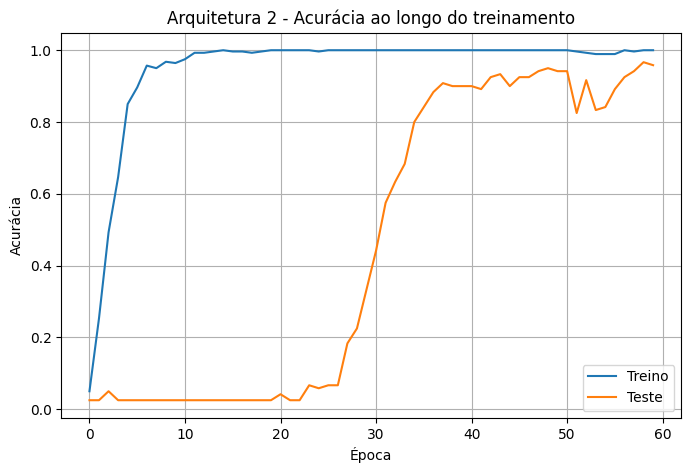

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history2.history['accuracy'], label='Treino')
plt.plot(history2.history['val_accuracy'], label='Teste')
plt.title('Arquitetura 2 - Acurácia ao longo do treinamento')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()


### 5.2 Avaliação - Arquitetura 2

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Acurácia (Arquitetura 2) no conjunto de teste: 95.83%


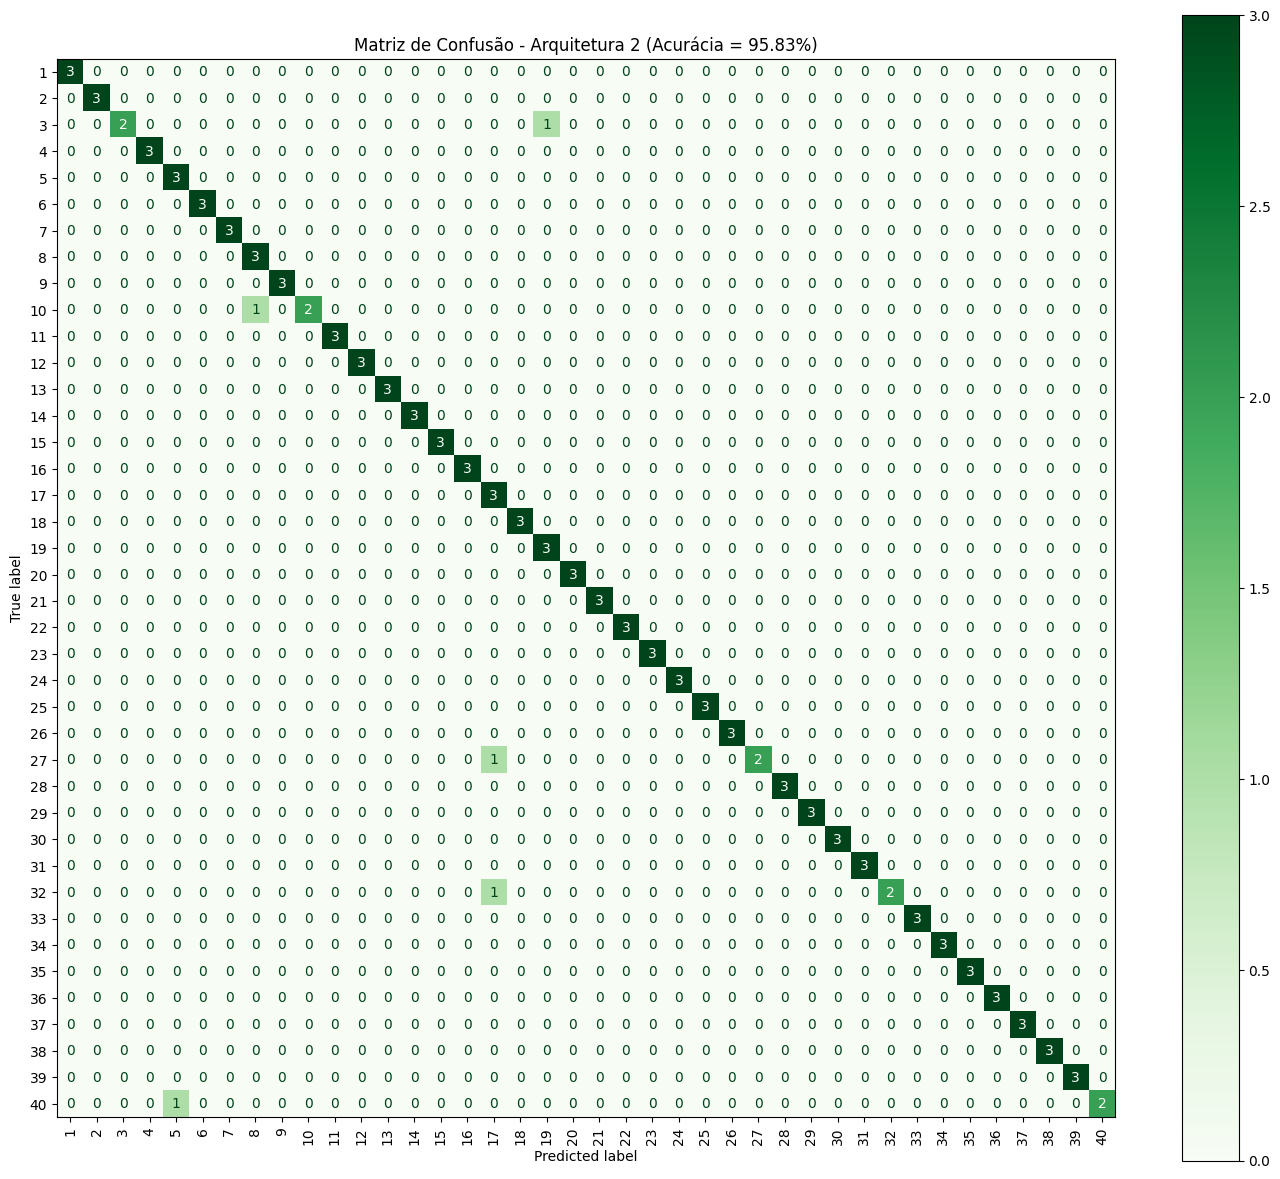

In [ ]:
y_pred2 = np.argmax(model2.predict(X_test), axis=1)

acc2 = accuracy_score(y_true, y_pred2)
print(f"Acurácia (Arquitetura 2) no conjunto de teste: {acc2*100:.2f}%")

cm2 = confusion_matrix(y_true, y_pred2, labels=range(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(14, 12))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2,
                                display_labels=[str(i+1) for i in range(NUM_CLASSES)])
disp2.plot(ax=ax, cmap='Greens', colorbar=True)
plt.title(f'Matriz de Confusão - Arquitetura 2 (Acurácia = {acc2*100:.2f}%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 6. Comparação dos resultados

A célula abaixo compara as curvas de acurácia de treino/teste das duas
arquiteturas em um único gráfico e resume as acurácias finais obtidas no
conjunto de teste.

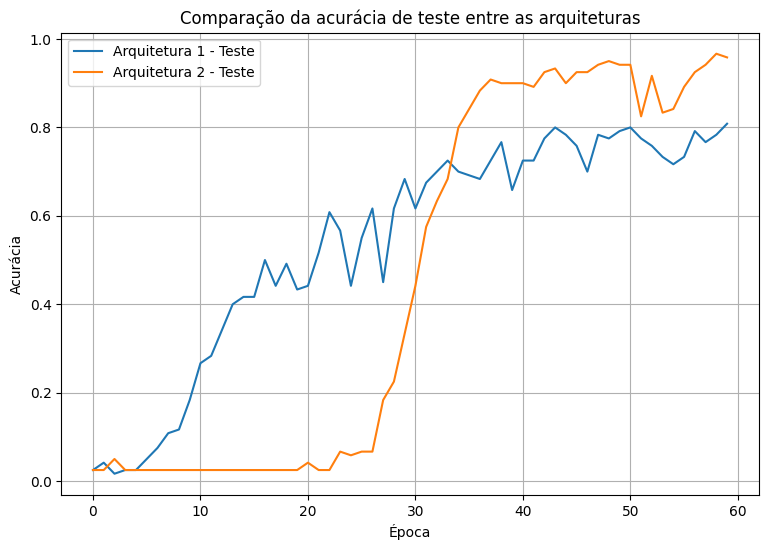

Acurácia final - Arquitetura 1: 80.83%
Acurácia final - Arquitetura 2: 95.83%


In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(history1.history['val_accuracy'], label='Arquitetura 1 - Teste')
plt.plot(history2.history['val_accuracy'], label='Arquitetura 2 - Teste')
plt.title('Comparação da acurácia de teste entre as arquiteturas')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

print(f"Acurácia final - Arquitetura 1: {acc1*100:.2f}%")
print(f"Acurácia final - Arquitetura 2: {acc2*100:.2f}%")